# RANDOMIZED CONTROLLED EXPERIMENTS AND CAUSALITY

### Mammography Screening Example

In this notebook, we use a randomized experiment to investigate whether mammography screening is associated with a lower rate of death from breast cancer.

**Learning goals**
- Understand treatment and control groups.
- Compare outcomes between two randomized groups.
- Calculate an observed difference in group means.
- Use a permutation test to represent the null hypothesis.
- Estimate and interpret a p-value.

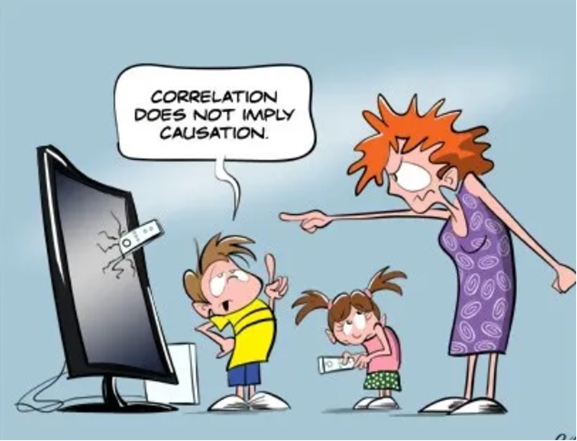

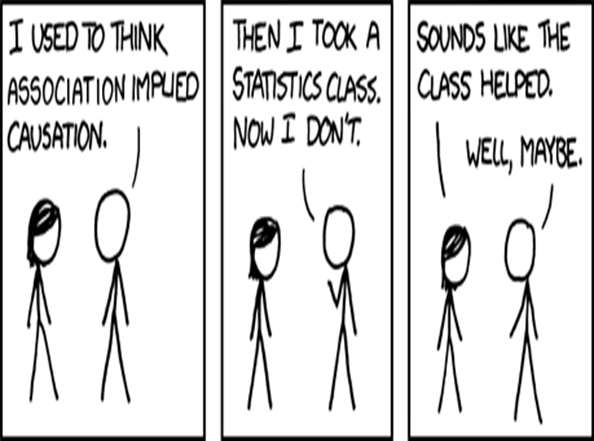

## 1. Import the required libraries

We use:
- **pandas** for working with tables.
- **NumPy** for numerical operations and random permutations.
- **Matplotlib** for visualizations.
- **google.colab.files** for uploading the dataset in Google Colab.

In [1]:
# Import the libraries needed for this notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots directly inside the notebook.
%matplotlib inline

# Colab utility used to upload mammogram.csv.
from google.colab import files

## 2. The randomized experiment

The study contains **89,835 women** who were assigned to either:

- **Mammogram group:** received mammography screening.
- **Control group:** did not receive the mammography screening intervention being tested.

The outcome recorded was whether a participant **died from breast cancer within 25 years**.

Because participants were randomized, the two groups can be compared to investigate whether the screening intervention caused a difference in the outcome.

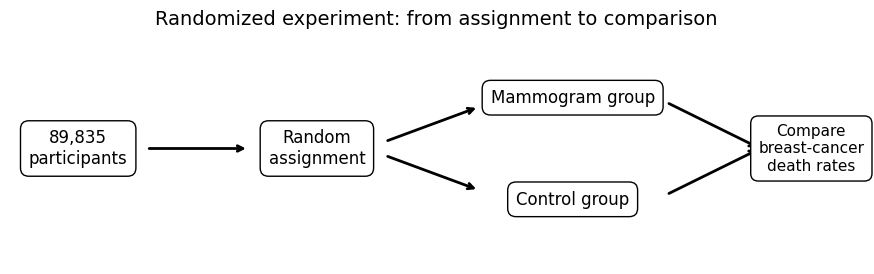

In [2]:
# Graphical illustration of the experimental design.
# This is a conceptual diagram, not a plot of the actual data.

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

ax.text(0.08, 0.5, "89,835\nparticipants",
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.annotate("", xy=(0.28, 0.5), xytext=(0.16, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.36, 0.5, "Random\nassignment",
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.annotate("", xy=(0.55, 0.68), xytext=(0.44, 0.53),
            arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.55, 0.32), xytext=(0.44, 0.47),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.66, 0.72, "Mammogram group",
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.text(0.66, 0.28, "Control group",
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white"))

ax.annotate("", xy=(0.88, 0.5), xytext=(0.77, 0.70),
            arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.88, 0.5), xytext=(0.77, 0.30),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.94, 0.5, "Compare\nbreast-cancer\ndeath rates",
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white"))

plt.title("Randomized experiment: from assignment to comparison", fontsize=14)
plt.show()

## 3. Research question and hypotheses

### Research question
**Does receiving mammography screening reduce the probability of dying from breast cancer compared with the control group?**

### Null hypothesis, H₀
There is **no real difference** in the breast-cancer death rates of the mammogram and control groups.

### Alternative hypothesis, H₁
The breast-cancer death rate is **lower in the mammogram group** than in the control group.

Because the research question asks whether mammography **reduces** the death rate, the permutation test below uses a **one-sided** p-value.

## 4. Upload and read the dataset

Upload the file **`mammogram.csv`** when prompted.

In [3]:
# Upload mammogram.csv from your computer.

#https://www.openintro.org/data/

#https://pmc.ncbi.nlm.nih.gov/articles/PMC4712234/

uploaded = files.upload()

Saving mammogram.csv to mammogram.csv


In [4]:
# Read the CSV file into a pandas DataFrame.
mammogram = pd.read_csv("mammogram.csv")




In [5]:
# Confirm the dimensions of the dataset.
print("Rows and columns:", mammogram.shape)

Rows and columns: (89835, 2)


In [6]:

# View the first five observations.
mammogram.head()

,treatment,breast_cancer_death
0,mammogram,yes
1,mammogram,yes
2,mammogram,yes
3,mammogram,yes
4,mammogram,yes


In [7]:
mammogram

,treatment,breast_cancer_death
0,mammogram,yes
1,mammogram,yes
2,mammogram,yes
3,mammogram,yes
4,mammogram,yes
...,...,...
89830,control,no
89831,control,no
89832,control,no
89833,control,no


## 5. Understand the variables

The dataset contains two original variables:

- **`treatment`**: identifies whether a participant was assigned to the `mammogram` or `control` group.
- **`breast_cancer_death`**: records whether the participant died from breast cancer (`yes` or `no`).

Each row represents one participant.

In [8]:
# Count the number of participants in each treatment group.
treatment_counts = mammogram["treatment"].value_counts()
treatment_counts

,count
treatment,
mammogram,44925
control,44910


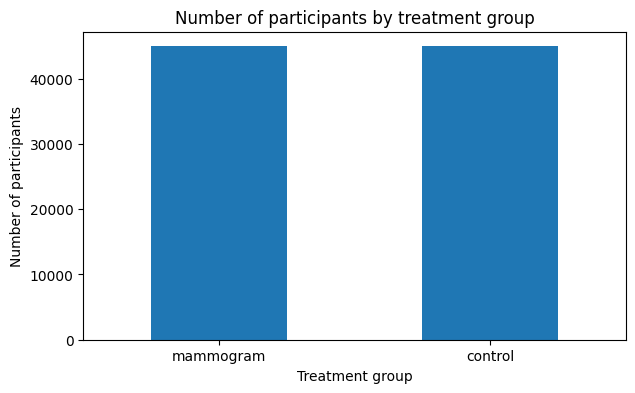

In [9]:
# Visualize the number of participants in each treatment group.
# Similar group sizes are expected in a randomized experiment.

ax = treatment_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Number of participants by treatment group")
ax.set_xlabel("Treatment group")
ax.set_ylabel("Number of participants")
plt.xticks(rotation=0)
plt.show()

In [10]:
# Count the breast-cancer death outcomes across the full dataset.
outcome_counts = mammogram["breast_cancer_death"].value_counts()
outcome_counts

,count
breast_cancer_death,
no,88830
yes,1005


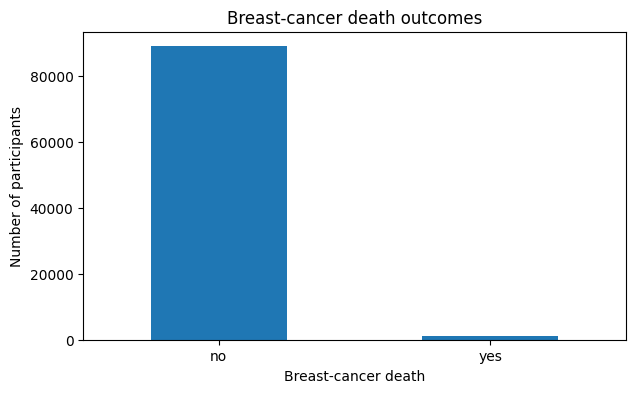

In [11]:
# Visualize the overall outcome counts.

ax = outcome_counts.plot(kind="bar", figsize=(7, 4))
ax.set_title("Breast-cancer death outcomes")
ax.set_xlabel("Breast-cancer death")
ax.set_ylabel("Number of participants")
plt.xticks(rotation=0)
plt.show()

## 6. Convert the outcome to a numerical indicator

Statistical calculations are easier when the outcome is numerical.

We create:

- `True` (or 1) when `breast_cancer_death == "yes"`
- `False` (or 0) when `breast_cancer_death == "no"`

The **mean** of this indicator within a group is therefore the **proportion of participants who died from breast cancer**.

In [12]:
# Create a Boolean indicator for breast-cancer death.
mammogram["indicator"] = mammogram["breast_cancer_death"] == "yes"

# View the first few rows.
mammogram.head()

,treatment,breast_cancer_death,indicator
0,mammogram,yes,True
1,mammogram,yes,True
2,mammogram,yes,True
3,mammogram,yes,True
4,mammogram,yes,True


In [14]:
# The original text outcome is no longer required for the calculations below.
# Drop it to keep the working table simple.
mammogram = mammogram.drop(columns=["breast_cancer_death"])

mammogram.head()

,treatment,indicator
0,mammogram,True
1,mammogram,True
2,mammogram,True
3,mammogram,True
4,mammogram,True


In [15]:
mammogram

,treatment,indicator
0,mammogram,True
1,mammogram,True
2,mammogram,True
3,mammogram,True
4,mammogram,True
...,...,...
89830,control,False
89831,control,False
89832,control,False
89833,control,False


In [16]:
# Count the values of the new indicator.
# False = did not die from breast cancer
# True  = died from breast cancer
mammogram["indicator"].value_counts()

,count
indicator,
False,88830
True,1005


## 7. Compare the observed death rates

Because `True` behaves like 1 and `False` behaves like 0 in a mean calculation, the average value of `indicator` is the **death rate** for each treatment group.

In [17]:
# Calculate the breast-cancer death rate for each treatment group.
death_rates = mammogram.groupby("treatment")["indicator"].mean()
death_rates

,indicator
treatment,
control,0.011245
mammogram,0.011130


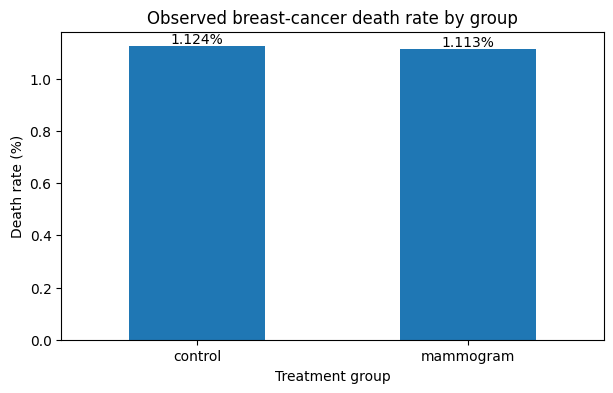

In [18]:
# Display the death rates as percentages.

death_rate_percent = death_rates * 100

ax = death_rate_percent.plot(kind="bar", figsize=(7, 4))
ax.set_title("Observed breast-cancer death rate by group")
ax.set_xlabel("Treatment group")
ax.set_ylabel("Death rate (%)")
plt.xticks(rotation=0)

# Add the percentage above each bar.
for i, value in enumerate(death_rate_percent):
    ax.text(i, value, f"{value:.3f}%", ha="center", va="bottom")

plt.show()

### What should we notice?

The two observed death rates are very close. The next step is to calculate their difference and ask whether a difference this small could reasonably occur **by chance** if the null hypothesis were true.

In [19]:
# Create a table of group means.
mean_table = mammogram.groupby("treatment")[["indicator"]].mean()
mean_table

,indicator
treatment,
control,0.011245
mammogram,0.011130


In [20]:
# Pandas sorts the treatment labels alphabetically:
# control comes first and mammogram comes second.
#
# Therefore:
# observed_difference = mammogram death rate - control death rate

observed_difference = (
    mean_table.loc["mammogram", "indicator"]
    - mean_table.loc["control", "indicator"]
)

print("Observed difference:", observed_difference)
print("Observed difference in percentage points:",
      observed_difference * 100)

Observed difference: -0.00011505110015988182
Observed difference in percentage points: -0.011505110015988182


A **negative** observed difference means the mammogram group had a slightly lower observed death rate than the control group.

However, an observed difference alone does not tell us whether the difference is convincing evidence of an effect. We therefore use a **permutation test**.

## 8. Permutation test

### The key idea

Under the **null hypothesis**, the treatment label should not be systematically related to the outcome.

So we:

1. Keep the observed outcomes fixed.
2. Randomly shuffle the treatment labels.
3. Recalculate the difference in death rates.
4. Repeat this many times.

These simulated differences show the kinds of differences we would expect **if there were really no treatment effect**.

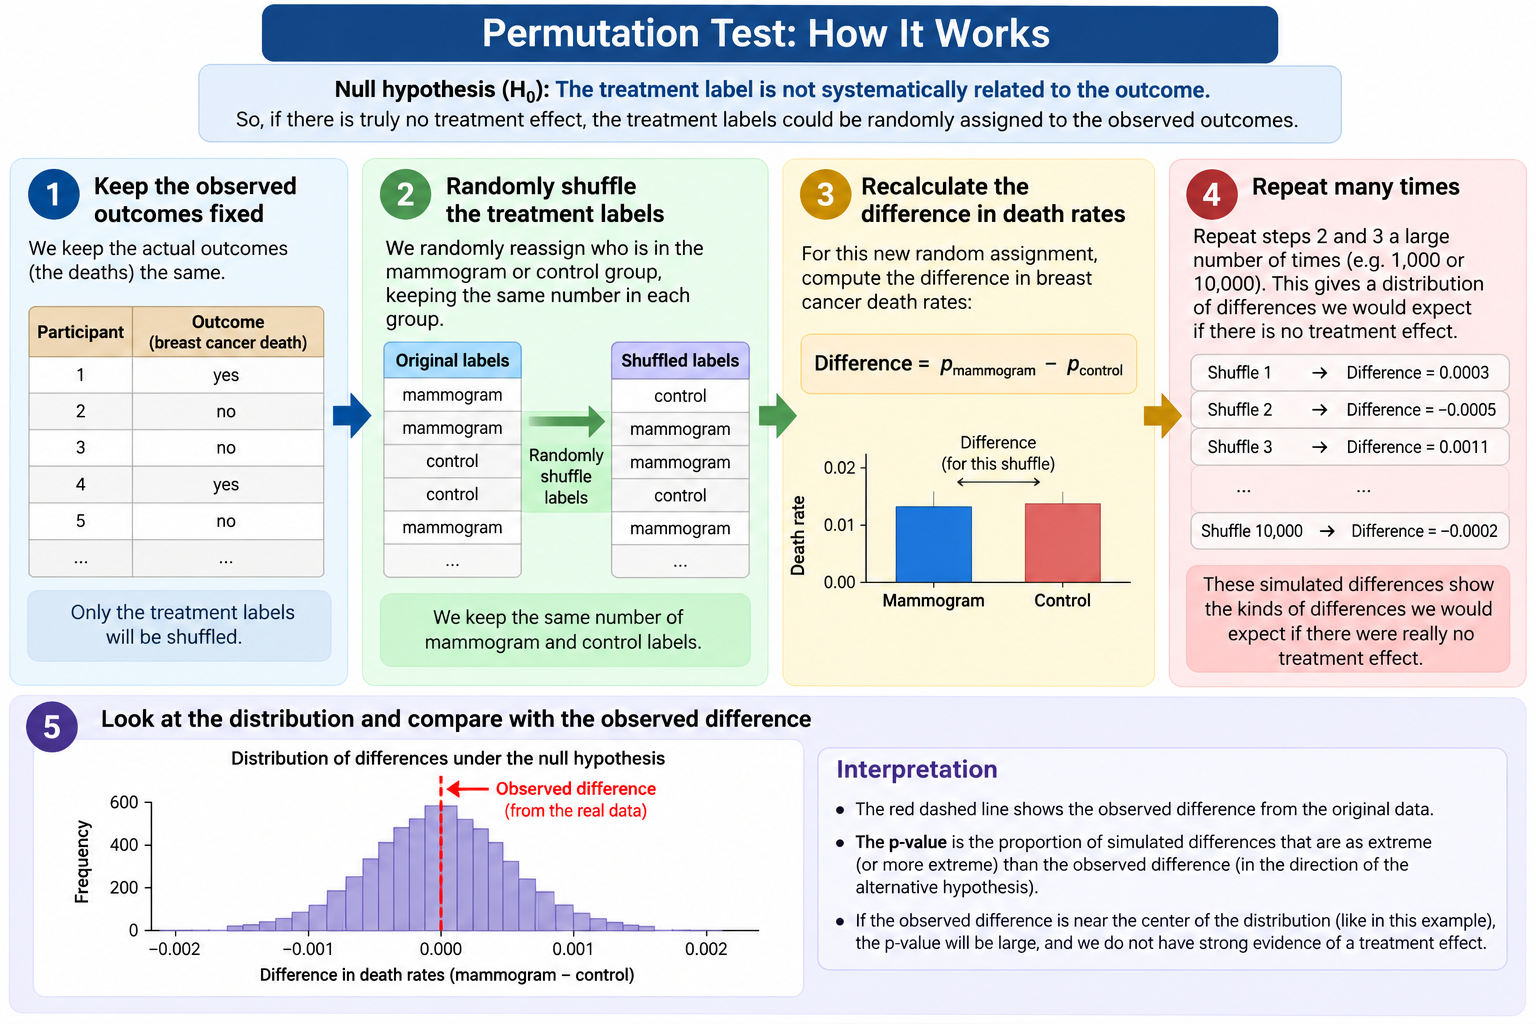

In [21]:
def difference_of_means(table, label, group_label):
    '''
    Calculate the difference in the mean outcome between
    the mammogram group and the control group.

    Parameters
    ----------
    table : pandas DataFrame
        Dataset containing the outcome and group labels.
    label : str
        Name of the numerical/Boolean outcome column.
    group_label : str
        Name of the column identifying the two groups.

    Returns
    -------
    float
        mean(mammogram) - mean(control)
    '''

    group_means = table.groupby(group_label)[label].mean()

    # For the original treatment labels, explicitly use the group names.
    if "mammogram" in group_means.index and "control" in group_means.index:
        return group_means.loc["mammogram"] - group_means.loc["control"]

    # For shuffled-label columns, pandas still contains the same two
    # labels, so this fallback simply subtracts the first from the second.
    return group_means.iloc[1] - group_means.iloc[0]

In [22]:
# Check that the function reproduces the observed difference.
difference_of_means(mammogram, "indicator", "treatment")

np.float64(-0.00011505110015988182)

In [23]:
mammogram

,treatment,indicator
0,mammogram,True
1,mammogram,True
2,mammogram,True
3,mammogram,True
4,mammogram,True
...,...,...
89830,control,False
89831,control,False
89832,control,False
89833,control,False


In [24]:
# Shuffle the treatment labels once.
# np.random.permutation keeps the same labels but changes who receives them.

shuffled_labels = np.random.permutation(mammogram["treatment"])

# Work on a copy so that the original mammogram table is not accidentally changed.
original_and_shuffled = mammogram.copy()
original_and_shuffled["Shuffled Label"] = shuffled_labels

# Compare the original and shuffled labels.
original_and_shuffled.head(10)

,treatment,indicator,Shuffled Label
0,mammogram,True,mammogram
1,mammogram,True,control
2,mammogram,True,control
3,mammogram,True,control
4,mammogram,True,mammogram
5,mammogram,True,control
6,mammogram,True,mammogram
7,mammogram,True,control
8,mammogram,True,control
9,mammogram,True,control


In [25]:
# Difference produced by one random shuffle.
difference_of_means(
    original_and_shuffled,
    "indicator",
    "Shuffled Label"
)

np.float64(-0.00024862933063306975)

In [26]:
def one_simulated_difference(table, label, group_label):
    '''
    Perform one permutation under the null hypothesis
    and return the simulated difference in group means.
    '''

    # Randomly shuffle the treatment labels.
    shuffled_labels = np.random.permutation(table[group_label])

    # Create a temporary table containing the outcome
    # and the shuffled treatment labels.
    simulated_table = table[[label]].copy()
    simulated_table["Shuffled Label"] = shuffled_labels

    # Calculate mammogram mean - control mean after shuffling.
    return difference_of_means(
        simulated_table,
        label,
        "Shuffled Label"
    )

In [27]:
# Test one simulation.
one_simulated_difference(mammogram, "indicator", "treatment")

np.float64(-0.0009165204829990146)

## 9. Repeat the simulation many times

A single shuffle tells us very little. We repeat the randomization many times to build the **null distribution**.

The random seed below makes the classroom demonstration reproducible.

In [28]:
# Set a seed so that students can reproduce the same simulation.
np.random.seed(42)

# Number of permutation trials.
n_simulations = 1000

differences = []

for i in range(n_simulations):
    new_difference = one_simulated_difference(
        mammogram,
        "indicator",
        "treatment"
    )
    differences.append(new_difference)

# Convert the Python list to a NumPy array.
differences = np.array(differences)

differences[:10]

array([-0.00056031,  0.00019663, -0.00149536,  0.00037474, -0.00176252,
       -0.00015958,  0.00037474,  0.00015211,  0.00010758, -0.00011505])

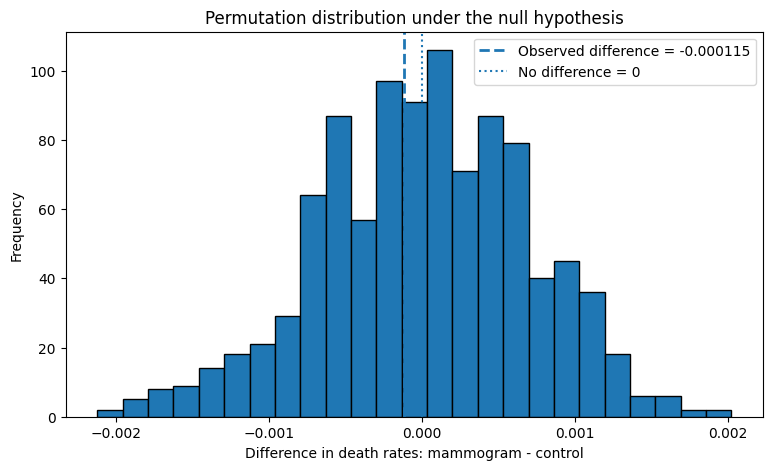

In [29]:
# Plot the null distribution and mark the observed difference.

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(differences, bins=25, edgecolor="black")
ax.axvline(
    observed_difference,
    linewidth=2,
    linestyle="--",
    label=f"Observed difference = {observed_difference:.6f}"
)

ax.axvline(
    0,
    linewidth=1.5,
    linestyle=":",
    label="No difference = 0"
)

ax.set_title("Permutation distribution under the null hypothesis")
ax.set_xlabel("Difference in death rates: mammogram - control")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

### Reading the null distribution

- Values near **0** represent little or no difference between the groups.
- The histogram shows differences generated purely by random reassignment.
- The dashed vertical line shows the **actual observed difference**.
- If the observed difference lies far into the relevant tail, it would be unusual under the null hypothesis.

## 10. Calculate the p-value

Because the alternative hypothesis is that the mammogram group has a **lower** death rate, we calculate a **left-tailed p-value**:

> What proportion of simulated differences are **less than or equal to** the observed difference?

In [30]:
# One-sided p-value for:
# H1: mammogram death rate < control death rate

p_value = np.mean(differences <= observed_difference)

print("Observed difference:", observed_difference)
print("P-value:", p_value)

Observed difference: -0.00011505110015988182
P-value: 0.43


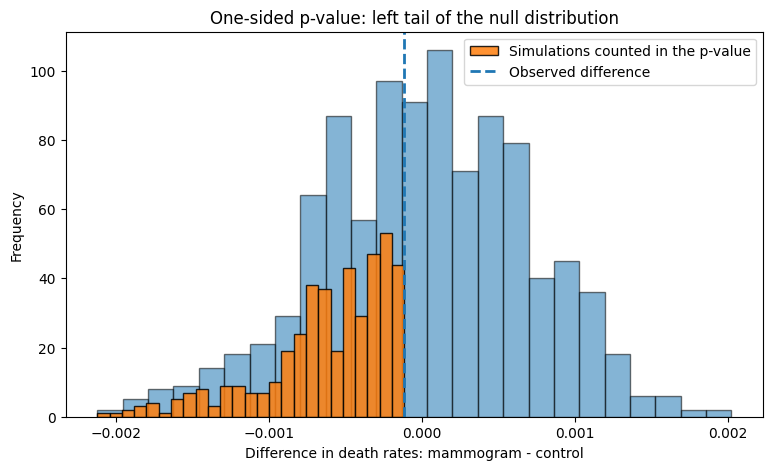

In [31]:
# Graphically show the simulations that contribute to the p-value.

fig, ax = plt.subplots(figsize=(9, 5))

# Plot all simulated differences.
ax.hist(differences, bins=25, edgecolor="black", alpha=0.55)

# Highlight the left-tail simulations at least as extreme
# as the observed difference.
tail = differences[differences <= observed_difference]
ax.hist(tail, bins=25, edgecolor="black", alpha=0.85,
        label="Simulations counted in the p-value")

# Mark the observed result.
ax.axvline(
    observed_difference,
    linewidth=2,
    linestyle="--",
    label="Observed difference"
)

ax.set_title("One-sided p-value: left tail of the null distribution")
ax.set_xlabel("Difference in death rates: mammogram - control")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

## 11. Interpret the result

Use a common significance level such as **α = 0.05**:

- If **p ≤ 0.05**, reject the null hypothesis.
- If **p > 0.05**, fail to reject the null hypothesis.

If your p-value is around **0.5**, the observed difference is quite ordinary under the null hypothesis. In that case, the data do **not provide strong statistical evidence** that the mammogram group had a lower breast-cancer death rate than the control group.

### Important wording

**Failing to reject the null hypothesis does not prove that the two groups are identical.**  
It means that the observed evidence is not strong enough, under this test, to conclude that the mammogram intervention reduced the breast-cancer death rate.

# Key Takeaways

1. **Randomization** makes treatment and control groups comparable.
2. A Boolean outcome can be converted to an **indicator**, whose mean is a proportion.
3. The **observed difference** summarizes the difference between the two groups.
4. **Permutation** creates results expected under the null hypothesis.
5. The **p-value** measures how unusual the observed result is under that null model.
6. Statistical significance and practical or clinical importance are **not the same thing**.